In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math



In [2]:
data = pd.read_csv("/home/patel-krish/BrainyBeam/heart.csv")

In [3]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [4]:
def minimum_value(values):

    minimum = values[0]

    for value in values:

        if value < minimum:
            minimum = value

    return minimum

In [5]:
def maximum_value(values):

    maximum = values[0]

    for value in values:

        if value > maximum:
            maximum = value

    return maximum

In [6]:
def kde(values, points, bandwidth):

    densities = []

    for point in points:

        total = 0

        for value in values:

            distance = (
                point - value
            ) / bandwidth

            kernel = math.exp(
                -0.5 * distance ** 2
            )

            total = total + kernel

        density = total / (
            len(values) *
            bandwidth *
            math.sqrt(2 * math.pi)
        )

        densities.append(density)

    return densities

In [7]:
def create_points(values):

    minimum = minimum_value(values)
    maximum = maximum_value(values)

    points = []

    steps = 50

    gap = (
        maximum - minimum
    ) / steps

    for i in range(steps + 1):

        point = minimum + (i * gap)

        points.append(point)

    return points

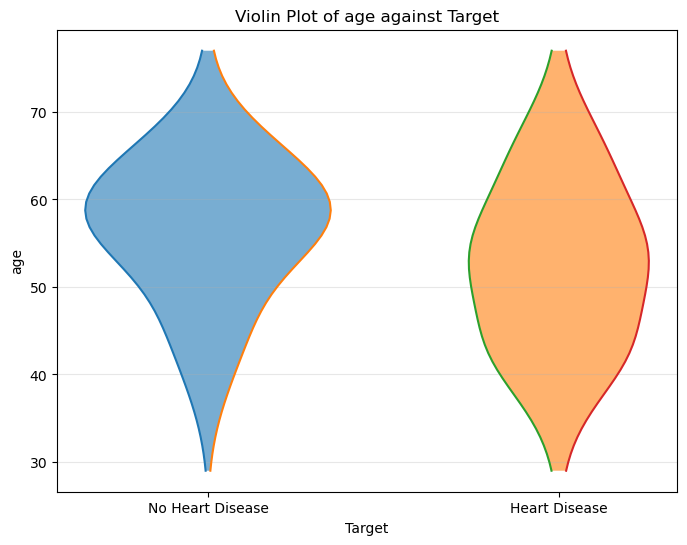

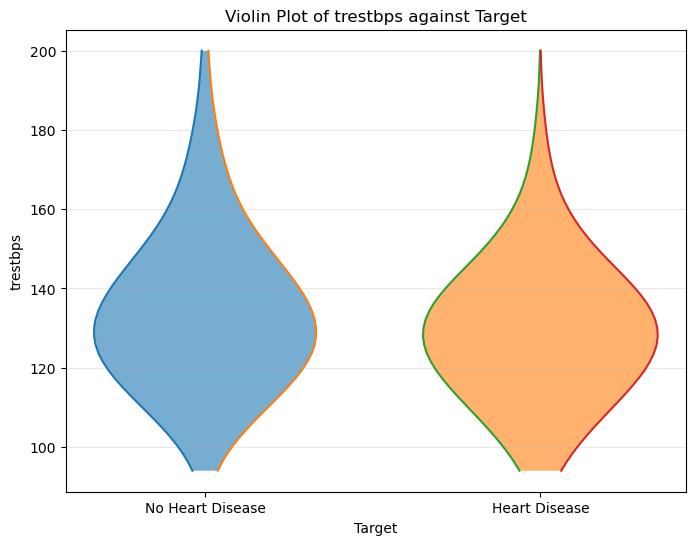

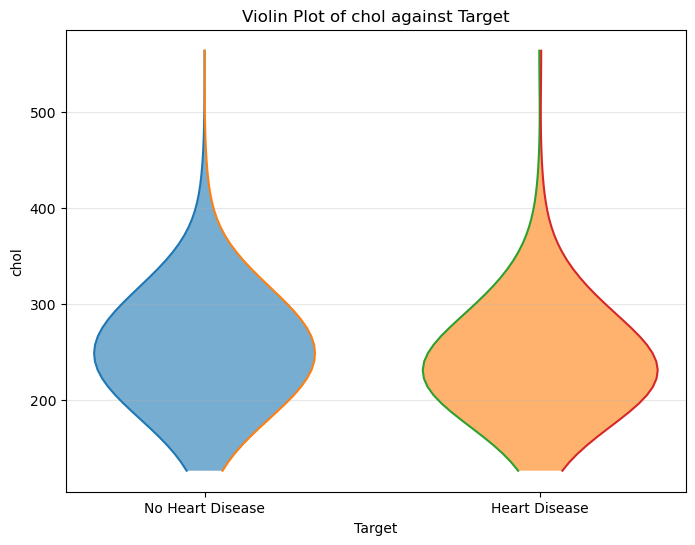

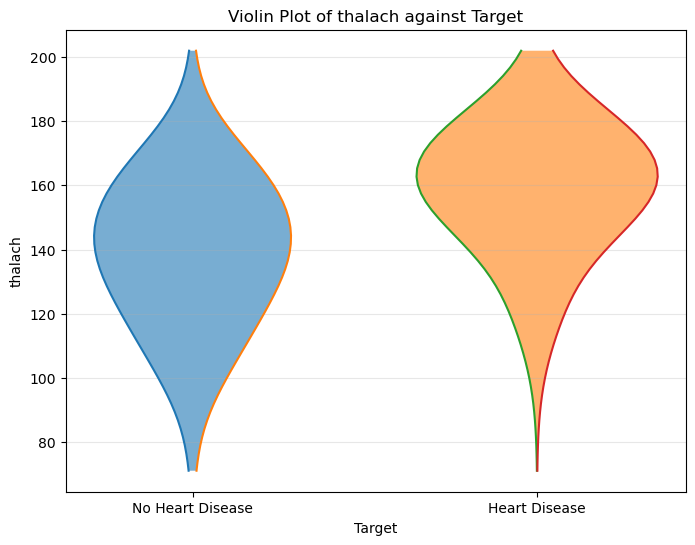

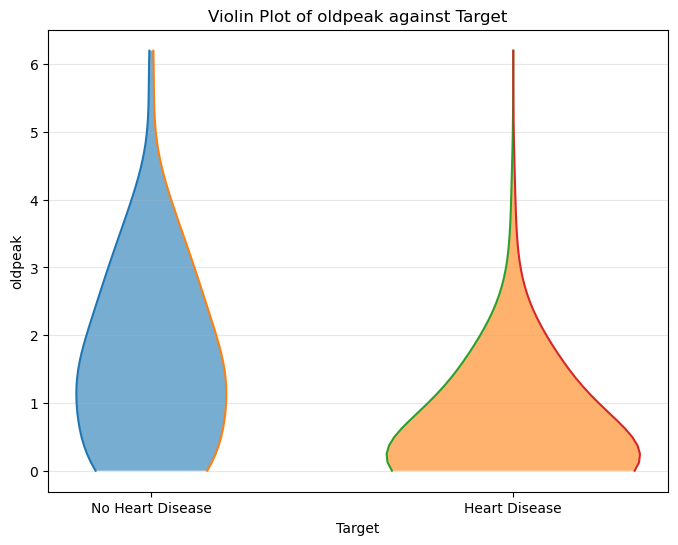

In [8]:
for column in numerical_columns:

    group_0 = list(
        data[data["target"] == 0][column]
    )

    group_1 = list(
        data[data["target"] == 1][column]
    )

    all_values = list(data[column])

    points = create_points(all_values)


    value_range = (
        maximum_value(all_values) -
        minimum_value(all_values)
    )

    bandwidth = value_range / 10

    if bandwidth == 0:
        bandwidth = 1


    density_0 = kde(
        group_0,
        points,
        bandwidth
    )

    density_1 = kde(
        group_1,
        points,
        bandwidth
    )


    max_density = 0

    for value in density_0:

        if value > max_density:
            max_density = value

    for value in density_1:

        if value > max_density:
            max_density = value


    width_0 = []
    width_1 = []


    for value in density_0:

        width_0.append(
            (value / max_density) * 0.35
        )


    for value in density_1:

        width_1.append(
            (value / max_density) * 0.35
        )


    left_0 = []
    right_0 = []

    left_1 = []
    right_1 = []


    for width in width_0:

        left_0.append(0 - width)
        right_0.append(0 + width)


    for width in width_1:

        left_1.append(1 - width)
        right_1.append(1 + width)


    plt.figure(figsize=(8, 6))


    plt.fill_betweenx(
        points,
        left_0,
        right_0,
        alpha=0.6
    )


    plt.fill_betweenx(
        points,
        left_1,
        right_1,
        alpha=0.6
    )


    plt.plot(left_0, points)
    plt.plot(right_0, points)

    plt.plot(left_1, points)
    plt.plot(right_1, points)


    plt.xticks(
        [0, 1],
        [
            "No Heart Disease",
            "Heart Disease"
        ]
    )


    plt.title(
        "Violin Plot of " +
        column +
        " against Target"
    )

    plt.xlabel("Target")

    plt.ylabel(column)

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.show()